# Images and Image Processing

This notebook will enable you to gain basic knowledge of
image manipulation using Python and give you a taster of
more complex types of image processing, such as are
explored in the Computer Vision sub-field of AI.

There are several methods and tools available that provide
different but overlapping image handling capabilities.
Here we shall look at:

* Displaying images in markdown cells
* Using `IPython.display` to load and display images in Jupyter
* Using the Python Image Library, `PIL`
* Basic usage of `OpenCV` a powerful library supporting advanced
  image processing operations
* Displaying images using `matplotlib`

## Loading and displaying images

#### Displaying an image in markdown

We can display an image directly in a Jupyter markdown cell using
the following form of syntax:
```md
![The Yew Bush on the Knot](images/Yew-bush-on-the-Knot.jpg)
```
Here, `images/Yew-bush-on-the-Knot.jpg` is the path (in this case
a relative path) to the image file.
Assuming the image file can be found by means of this path,
the image should display as follows:

![The Yew Bush on the Knot](images/Yew-bush-on-the-Knot.jpg)


If the image is not found the alternative text, enclosed in the
square brackets in the markdown image syntax, will be displayed instead of the image.

#### Displaying an image in markdown via HTML

We can also display an image in markdown using an HTML `img` element.
This has the advantage that we can alter the size at which the image
is displayed by specifying a `width` attribute:

```md
<img src="images/my_caterpillar.jpg" width="250">
```

<img src="images/my_caterpillar.jpg" width="250">


#### Loading and displaying images using IPython.display
The `IPython.display` module provides some convenient functionality
for loading and displaying images using Python running within the Jupyter environment.
This is illustrated in the following code cell:

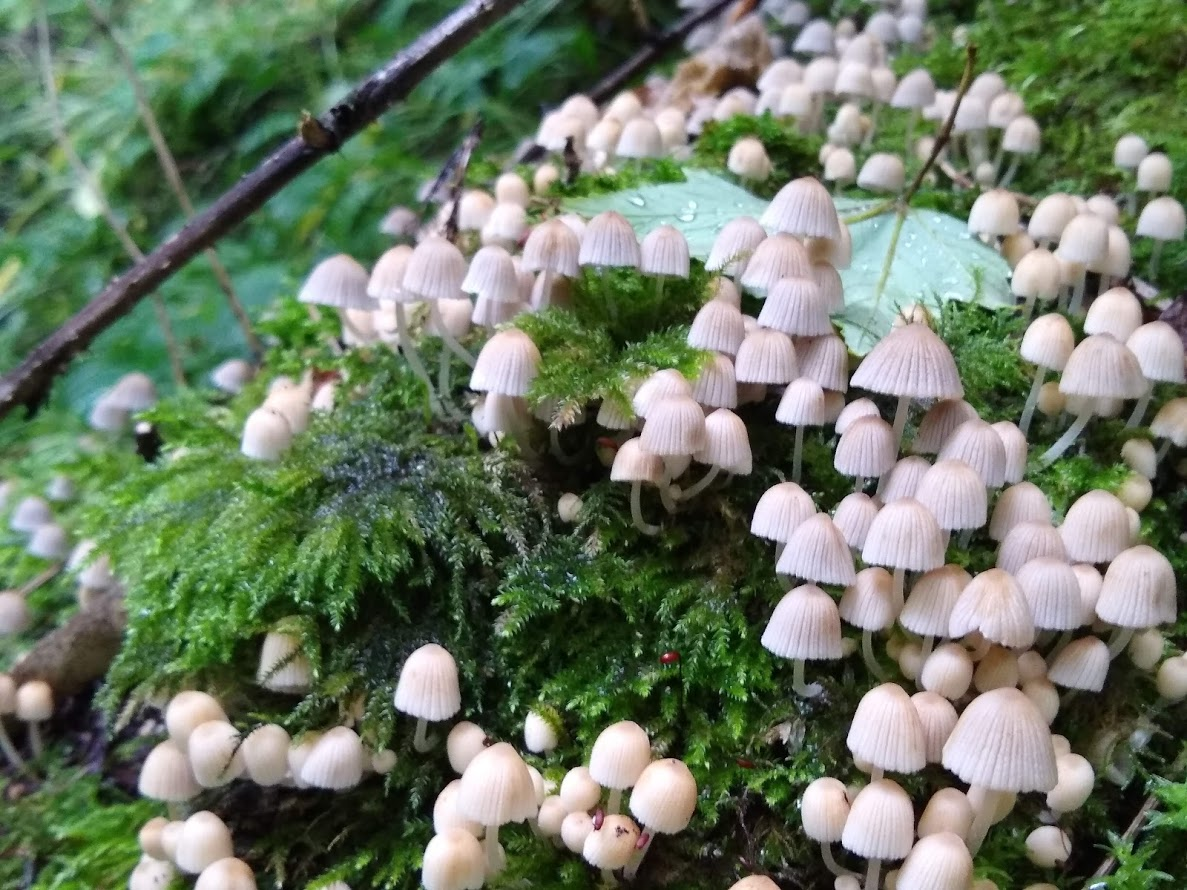

In [1]:
from IPython.display import Image
image = Image('images/mushrooms-skipton-woods.jpg', width=400)
display(image)

## PIL: the Python Image Library

The Python Image Library (PIL) is currently packaged under the
name `pillow`. To use it you will need to install this package.
If using `conda` in a shell you would enter the command:
```
conda install pillow
```
The following code cell illustrates reading a PIL image from
a file and displaying it using Jupyter's `display` funcition.
The `reduce` method of PIL images has also been used to make
the image smaller (by a factor of 10).

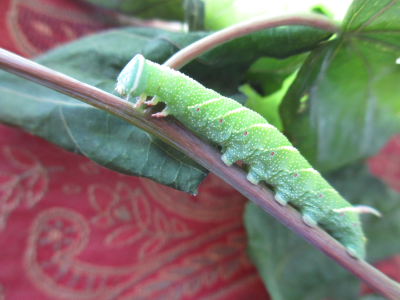

In [1]:
import PIL.Image
pil_image = PIL.Image.open("images/my_caterpillar.jpg")
display(pil_image.reduce(10))
#display(pil_image)

#### Displaying PIL images using `matplotlib`
A nice feature of PIL images is that you can display them directly 
using the `matplotlib.pyplot.imshow` function. 
The way it does this is by using the `numpy.array`
function, which works with many types of data object. But you don't need
to worry about that to display a PIL image because it is done automatically. It also automatically scales the image to fit the
plot display. The following code illustrates this:

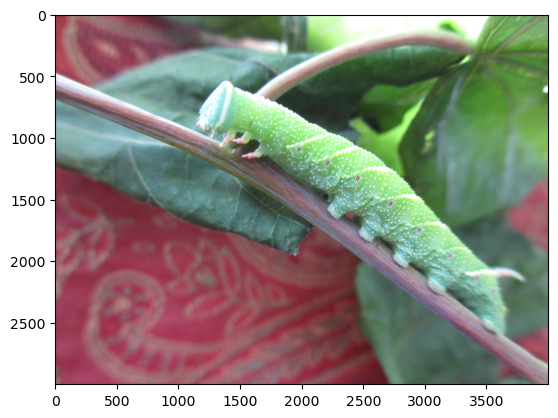

In [4]:
import matplotlib.pyplot as plt
plt.imshow(pil_image)

## OpenCV

Whereas PIL is aimed at providing convenient tools for 
converting between different image formats, and basic image
manipulation functionality, [OpenCV](https://opencv.org/) is a 
much more elaborate
software library designed to support the developement of
AI computer vision systems.

OpenCV is written in C++ but has become a cross-platform system
with interfaces available for several other languages, including
Python. Although Python is for many purposes slower than C++ and
image processing involves intensive computation, the Python interface
makes use of `numpy` data structures and other C++
components that can be embedded within Python. Hence, OpenCV operations
carried out via Python can be as efficient as when run in  C++.

To run the following code, you will need to install the `opencv` package:
```
conda install opencv
```

#### OpenCV Images are `numpy` arrays
In the following code we import an image from a file into an OpenCV image datastructure, using `cv2.imread`. We then print its type as well as the image object itself. We see that the image is just an n-dimensional `numpy` array. The code `cv2_image.shape` is using the `shape` attribute,
which all `numpy.array` objects have. This gives the size of each dimension of the array, in this case `(3000, 4000, 3)`.  This corresponds
to the image being `3000 * 4000` pixels in size, with each pixel being represented by three pixels, one for each of the three primary colours.

In [ ]:
import cv2
cv2_image = cv2.imread("images/my_caterpillar.jpg")
print("Type:", type(cv2_image))
print("Array shape:", cv2_image.shape)
print(cv2_image)

### Displaying OpenCV in Matplotlib
Since OpenCVs image format is an array format, OpenCV images can also
be displayed directly using `matplotlib`. However, there is a slight
problem, which is shown by the code below:

In [ ]:
import cv2
import matplotlib.pyplot as plt

pil_image = PIL.Image.open("images/Parkinson-Building-glowing.jpg")
cv2_image = cv2.imread("images/Parkinson-Building-glowing.jpg")

fig, axs = plt.subplots(1,2, figsize =(10,10))
axs[0].imshow(pil_image) 
axs[1].imshow(cv2_image)

Clearly the images look a lot different in terms of colour.
This is because OpenCV uses a different colour representation
from PIL. Whereas PIL uses the widely used ordering of red, green, blue
in its colour representation, OpenCV actually uses the order blue, green and
red. Matplotlibs `imshow` just processes images in terms of an array of pixels and assumes the more common red, green, blue ordering. 
Hence, the image displayed in the right hand plot has the red and blue
colour values swapped over. Thus, the red brick of Leeds University's Great Hall looks blue, and the blue-grey sky looks brown.

#### Swapping red and blue color values
Given that we are programmers and the images are just array datastructures, it is actually fairly easy for us to swap the
blue and red colour values in the image representation.

One could actually do it quite easily with a for loop. However,
OpenCV provides `split` and `merge` operations, which are a 
give us a convenient way to split up and rearange the colour
channels:

In [ ]:
def swap_b_r( image ):
    b,g,r = cv2.split(image)
    return  cv2.merge((r,g,b))

However, in my research into PIL and OpenCV, I found that the  way of conversion used in the code below is often suggested, 
and is said to be faster. The code makes use of a rather cryptic 
but very Pythonic slicing operator. The comma
separated parts of the slice operation represent slices on the three
dimensions of the array (rows, columns, colour-values). `:` is the
unbounded slice giving all elemnents, `::-1` also gives all elements
but orders them backwards. This means that the three colour values
will be reversed in order.

In [ ]:
def swap_b_r( image ):
    return image[:,:, ::-1]
    

In [ ]:
import cv2
import matplotlib.pyplot as plt

pil_image = PIL.Image.open("images/Parkinson-Building-glowing.jpg")
cv2_image = cv2.imread("images/Parkinson-Building-glowing.jpg")
swapped_cv2_image = swap_b_r(cv2_image)

fig, axs = plt.subplots(1,2, figsize =(10,10))
axs[0].imshow(pil_image) 
axs[1].imshow(swapped_cv2_image)

#### Converting between PIL and OpenCV Formats

##### OpenCV to PIL
We can convert an OpenCV image to a PIL image object by usining the function `PIL.Image.fromarray` which creates PIL image from an
image stored as an array (such as an OpenCV image). This is illustrated
by the code below. Note that we are here using `swap_b_r` to swap over
the blue and red colour values:

In [ ]:
import numpy
cv2_image = cv2.imread("images/Bee-on-Blossom.jpg")
cv2_image = swap_b_r(cv2_image)
pil_image = PIL.Image.fromarray(cv2_image)

display( pil_image.reduce(15) )

Since OpenCV is convenient for manipulating images but PIL has advantages
for viewing them in Jupyter, it will be useful to define the following
conversion function. Here I have included an optional scale argument
to resize the image, as well as using the `swap_b_r` function of course.

In [ ]:
def convert_cv2_to_pil(cv2_image, scale=1):
    height, width = cv2_image.shape[0:2]
    newsize = (int(width*scale), int(height*scale))
    cv2_image = cv2.resize( cv2_image, newsize )
    cv2_image = swap_b_r(cv2_image)
    pil_image = PIL.Image.fromarray(cv2_image)
    return pil_image

##### PIL to OpenCV
To convert the other way, from PIL to OpenCV format, we can explicitly use the `numpy.array` fucntion, which will turn a PIL image into an OpenCV compatible array format. We should also swap the blue and red colour chanels so that the colours are represented in the way used by OpenCV.
This is illustrated as follows:

In [ ]:
pil_image = PIL.Image.open("images/Bee-on-Blossom.jpg")
pil_image = pil_image.reduce(15)
cv2_image = numpy.array(pil_image)
cv2_image = swap_b_r(cv2_image)

plt.imshow(cv2_image)

So why have the colours turned creepy? This just because `imshow` does not interpret the OpenCV colour representation correctly.

### Using OpenCV to take a snapshot
As well as supporting sophisticated image processing operations,
OpenCV also provides a more basic function that is not directly
available using PIL. OpenCV enables one to access videos and images
directly from a webcam. Here we shall just look at getting a
snapshot image from webcam, which is illustrated by the following code:

In [ ]:
import cv2       # OpenCV package
import PIL.Image # Python Imaging Library

# Specify the device number of the default webcam input
# If just one it will normally be 0
DEFAULT_CAM = 0

def snapshot(cam=DEFAULT_CAM):
    cam = cv2.VideoCapture(cam)
    success, image = cam.read()
    cam.release()
    if success:
        return image
    else:
        print("!!! Couldn't take snapshot !!!")
        return None

If you have multiple cameras you can change the `cam` argument to select one other than the default cam number 0. You will probably find that even a cheap external web cam is more convenient and better quality than one that is built into a laptop.

Using the `snapshot` function, we can now define a simple function
that will take a picture using your webcam and display the result.
When you run this, you may find it doesn't work at first. This may just be that the webcam is not ready for action. Possibly if you run it again it will work.

In [ ]:
def show_snapshot(cam=DEFAULT_CAM):
    cv2_image = snapshot(cam=cam)
    pil_image = convert_cv2_to_pil( cv2_image, scale=0.5)
    display( pil_image )
    
show_snapshot()

### Colour Analysis: what is grey?
Although _colour_ is not a property that is often investigated in data, consideration of the concept of colour can be very instructive for a data scientist. This is because, although colour may appear to be a simple and intuitive type of data, the nature of colour is extremely complex. To understand it fully one would need to consider
aspects involving many fields of knowledge including physics, biology
psychology and more. All these aspects could have some bearing on
representation and analysis of colour.

Here we shall just look at one relatively simple issue, which is
the relationship between colour and grey scale images; and specifically,
how to create a grey scale image from a colour image.

One thing we may know is that gray scale images can be represented
by just one number representing the brightness of each pixel.
However, in a red, green, blue (or blue, green, red) representation
we have three different values. Thus, if an image is grey we may
suppose that we should have the same number for each of these
values. Is this true? If so why?

Well, actually it is true, but the reason is not simple.
There is no clear reason why grey should result from equal 
quantities of red, green and blue; and it is not even clear
what would be meant by equal quantities of different colours
(do we mean the same number of photons, or maybe the same
energy content in the different colours). What even is grey?
Is it really a colour? You don't see it in rainbows. But
clouds can definitely be grey.

If we assume that the colour values of each of the
three colour components make equal contribution to the
brightness of the image, that would imply that the
equivalent value of a pixel in a corresponding grey
image would simply be the average of the three colour
components. This idea is implemented in the following
code. Notice that the code expression `(b+g+r)//3`
makes use of the fact that the `b`, `g` and `r` chanels
that are split out of the image are in fact `numpy.array`
vectors. Hence, the operations `+` and `//`, are applied to 
the arrays as a whole, so we do not need to iterate over individual
items of the arays. `//` is used rather than `/` to ensure that
the resulting grey value array contains integers, which is what
is required for the image representation.

In [ ]:
def make_grey1( image ):
    b,g,r = cv2.split(image)
    av = (b+g+r)//3
    return  cv2.merge((av,av,av))

image = snapshot()
grey_image1 = make_grey1( image )
plt.imshow(grey_image1)

Well, that is not a pretty sight. The resulting image is certainly grey, but it looks very dark and weird.

The reason for this, is that the hypothesis that grey level
is made up equally from the intensity values of the three component colours is wrong. Actually things that look grey are, in terms of
the red, green, values, much more blue than they are green.  Hence,
to go from a colour image to a realistic grey image, we need to
scale down the blue and scale up the green.

After some investigation, I found the following unequal scaling
equation that can be used to transform red, green, blue values to
a grey scale:
```
grey = (0.3 * red) + (0.59 * green) + (0.11 * blue)
```
The code below implements this weighted sum calculation for
the grey scale vale.
The output plot compares the grey image obtained from each
of the caluclutions. It confirms that the weighted sum gives
a much more natural seeming grey image.

In [ ]:
def make_grey2( image ):
    b,g,r = cv2.split(image)
    grey = ((0.3 * r) + (0.59 * g) + (0.11 * b))/256
    return  cv2.merge( (grey,grey,grey) )

image = snapshot()
grey_image1 = make_grey1( image )
grey_image2 = make_grey2( image )

fig, axs = plt.subplots(1,2, figsize =(10,10))
axs[0].imshow( grey_image1 ) 
axs[1].imshow( grey_image2 )

## Edge Detection using OpenCV
Finally we shall take a quick look at one of the image processing techniques that is often used in the Computer Vision sub-field of Artificial Intelligence: in particular, edge detection using the
[Canny Edge Detector](https://en.wikipedia.org/wiki/Canny_edge_detector)
method.

In [ ]:
image = snapshot()

## Use OpenCVs built in colour representation mapping
## to get a grey scale image.
grey_cv2_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

## Use the standard OpenCV Canny edge detector:
edge_cv2_image = cv2.Canny( grey_cv2_image, 50, 100)

## This line inverts the image to give black lines on white
edge_cv2_image = 255 - edge_cv2_image

edge_pil_image = PIL.Image.fromarray( edge_cv2_image)
display( edge_pil_image )

## Resources for further study of Image Processing

I got a lot of ideas regarding image processing with Python from the following two tutorial resources. Note that they are not using exactly the Python3/Jupyter setup that we are using in this module, so some of the code will need modification. But they give a good idea of what is possible.

* [Making a simple GUI for image processing using Python's tikinter and cv2 packages](https://www.pyimagesearch.com/2016/05/23/opencv-with-tkinter/)

* [Video Analysis using OpenCV and Python](https://people.revoledu.com/kardi/tutorial/Python/Video+Analysis+using+OpenCV-Python.html)